In [1]:
# Do the necessary import
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
pickle_file = "HR_analytics_data_clean.pkl"

In [ ]:
# Lets verify that pickle file retained the data types 

df = pd.read_pickle(pickle_file)
print(df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int8    
 1   Attrition                 1470 non-null   bool    
 2   BusinessTravel            1470 non-null   category
 3   DailyRate                 1470 non-null   int16   
 4   Department                1470 non-null   category
 5   DistanceFromHome          1470 non-null   int8    
 6   Education                 1470 non-null   int8    
 7   EducationField            1470 non-null   category
 8   EnvironmentSatisfaction   1470 non-null   int8    
 9   Gender                    1470 non-null   category
 10  HourlyRate                1470 non-null   int8    
 11  JobInvolvement            1470 non-null   int8    
 12  JobLevel                  1470 non-null   int8    
 13  JobRole                   1470 non-null   catego

### Lets check Attrition by Department, Gender, EducationField, JobRole

In [3]:
# step1: Attrition percentage by Department:
col = 'Department'

# Step 1: Create a crosstab (frequency table)
ct = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100
print(f"\nAttrition percentage by {col}:")
print(ct.round(1))

ct_raw = pd.crosstab(df[col], df['Attrition'] )
print(f"\nAttrition raw count by {col}:")
print(ct_raw)



Attrition percentage by Department:
Attrition               False  True 
Department                          
Human Resources          81.0   19.0
Research & Development   86.2   13.8
Sales                    79.4   20.6

Attrition raw count by Department:
Attrition               False  True 
Department                          
Human Resources            51     12
Research & Development    828    133
Sales                     354     92


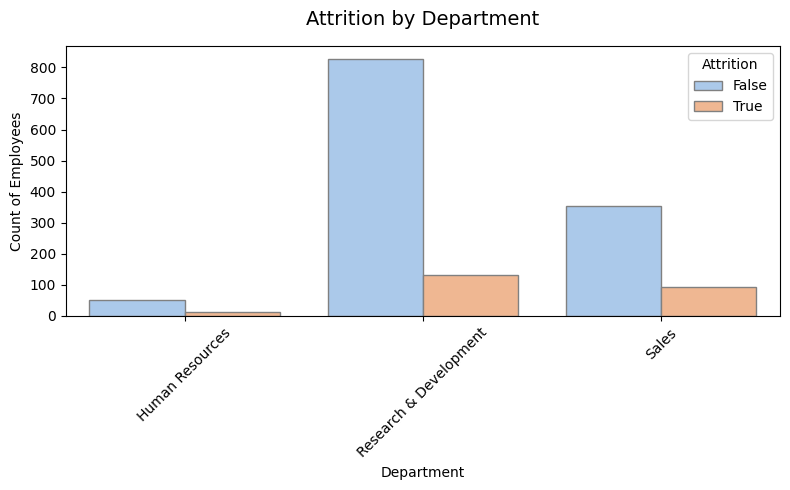

In [4]:
# Step 2: Visualization — grouped bar chart
col = 'Department'

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=col, hue='Attrition', palette='pastel', edgecolor='gray')

plt.title(f'Attrition by {col}', fontsize=14, pad=15)
plt.xlabel(col)
plt.ylabel('Count of Employees')
plt.xticks(rotation=45)
plt.legend(title='Attrition', loc='upper right')

plt.tight_layout()
plt.show()

# Observation: R and D department do not have large Attrition

In [5]:
# Step3: Now we scale it up: Attrition by Gender, EducationField, JobRole

columns = ["Gender", "EducationField", "JobRole"]

for col in columns:
        
    # Step 1: Create a crosstab (frequency table)
    ct = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100
    print(f"\nAttrition percentage by {col}:")
    print(ct.round(1))
    
    ct_raw = pd.crosstab(df[col], df['Attrition'] )
    print(f"\nAttrition by {col}:")
    print(ct_raw)
    print("\n+++++++++++++++++++++++++++++++\n")



Attrition percentage by Gender:
Attrition  False  True 
Gender                 
Female      85.2   14.8
Male        83.0   17.0

Attrition by Gender:
Attrition  False  True 
Gender                 
Female       501     87
Male         732    150

+++++++++++++++++++++++++++++++


Attrition percentage by EducationField:
Attrition         False  True 
EducationField                
Human Resources    74.1   25.9
Life Sciences      85.3   14.7
Marketing          78.0   22.0
Medical            86.4   13.6
Other              86.6   13.4
Technical Degree   75.8   24.2

Attrition by EducationField:
Attrition         False  True 
EducationField                
Human Resources      20      7
Life Sciences       517     89
Marketing           124     35
Medical             401     63
Other                71     11
Technical Degree    100     32

+++++++++++++++++++++++++++++++


Attrition percentage by JobRole:
Attrition                  False  True 
JobRole                                
Heal

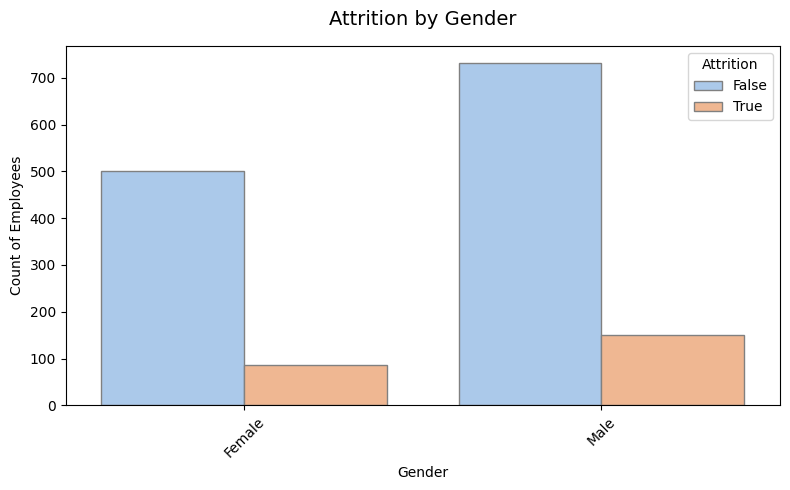

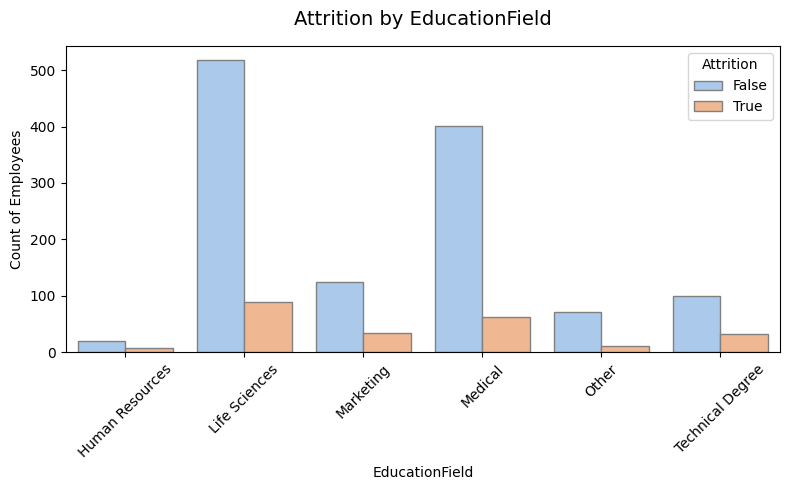

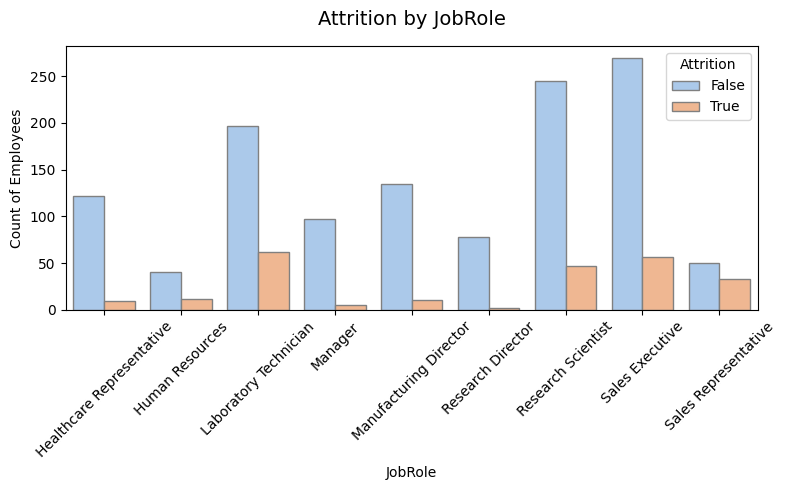

In [6]:
# Step 2: Visualization — grouped bar chart
columns = ["Gender", "EducationField", "JobRole"]

for col in columns:

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue='Attrition', palette='pastel', edgecolor='gray')
    
    plt.title(f'Attrition by {col}', fontsize=14, pad=15)
    plt.xlabel(col)
    plt.ylabel('Count of Employees')
    plt.xticks(rotation=45)
    plt.legend(title='Attrition', loc='upper right')
    
    plt.tight_layout()
    plt.show()
    print("\n\n\n")
    

    # Observation: 

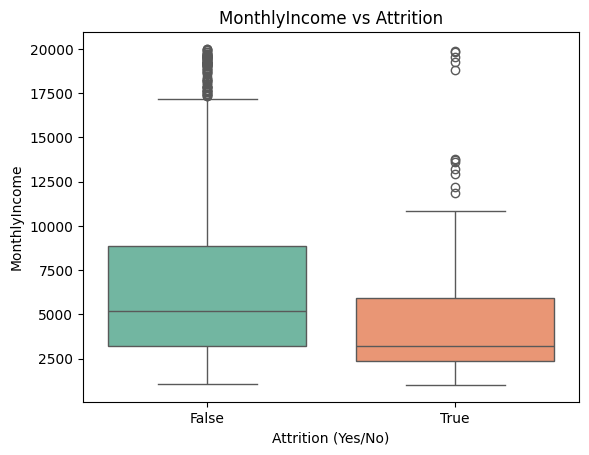

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
False,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
True,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


In [23]:
# visually compare the distributions of MonthlyIncome for employees who left (Attrition = Yes) vs those who stayed (Attrition = No).
col = 'MonthlyIncome'

sns.boxplot(
    x='Attrition', 
    y=col, 
    hue='Attrition',          # <-- assign hue same as x
    data=df, 
    palette='Set2', 
    legend=False              # <-- suppress duplicate legend
)

plt.title(f'{col} vs Attrition')
plt.xlabel('Attrition (Yes/No)')
plt.ylabel(col)
plt.show()

df.groupby('Attrition')[col].describe()

                      MonthlyIncome  NumCompaniesWorked  PercentSalaryHike  \
MonthlyIncome              1.000000            0.149515          -0.027269   
NumCompaniesWorked         0.149515            1.000000          -0.010238   
PercentSalaryHike         -0.027269           -0.010238           1.000000   
TotalWorkingYears          0.772893            0.237639          -0.020608   
HourlyRate                -0.015794            0.022157          -0.009062   
YearsInCurrentRole         0.363818           -0.090754          -0.001520   
YearsWithCurrManager       0.344079           -0.110319          -0.011985   

                      TotalWorkingYears  HourlyRate  YearsInCurrentRole  \
MonthlyIncome                  0.772893   -0.015794            0.363818   
NumCompaniesWorked             0.237639    0.022157           -0.090754   
PercentSalaryHike             -0.020608   -0.009062           -0.001520   
TotalWorkingYears              1.000000   -0.002334            0.460365   


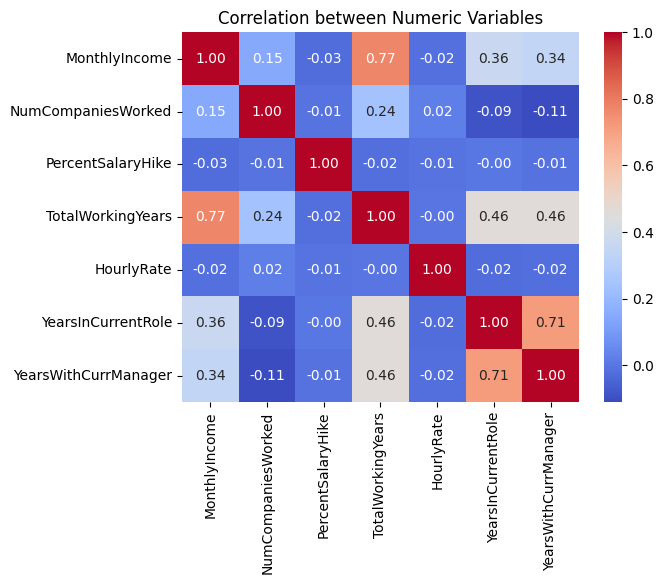

In [7]:
# Now lets do correlation between numeric columns
numeric_columns = [
    'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 
    'TotalWorkingYears', 'HourlyRate', 'YearsInCurrentRole', 'YearsWithCurrManager'
]

corr_matrix = df[numeric_columns].corr()
print(corr_matrix)
print("\n\n+++++++++++++++++++++\n\n")
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between Numeric Variables")
plt.show()

# observ: strong positive correlation between MonthlyIncome  and TotalWorkingYears
# strong positive correlation between YearsInCurrentRole and YearsWithCurrManager    


# Feature Relationships & Insights

## Age vs Attrition → Are younger employees leaving more?

In [8]:
print(df["Attrition"])

0        True
1       False
2        True
3       False
4       False
        ...  
1465    False
1466    False
1467    False
1468    False
1469    False
Name: Attrition, Length: 1470, dtype: bool


In [ ]:
# df['Attrition_Flag'] = df['Attrition'].map({':1, 'No':0})

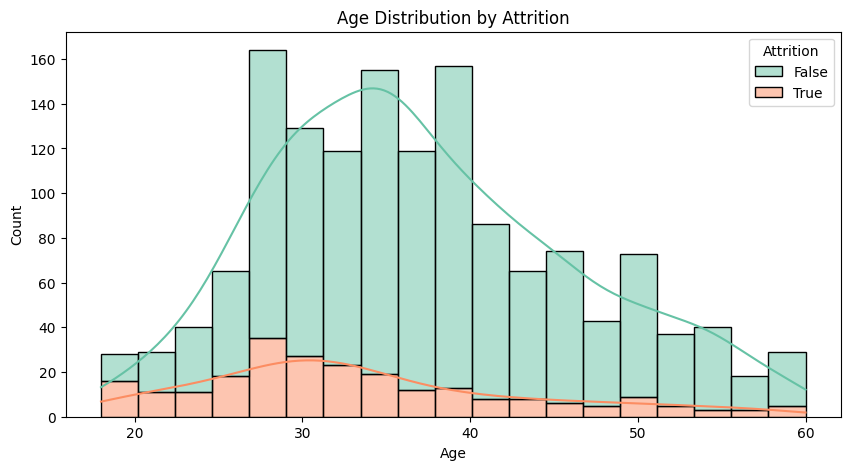

In [9]:
# 1) Simple visualization: Distribution by Age & Attrition

plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, multiple='stack', palette='Set2')
plt.title("Age Distribution by Attrition")
plt.show()

# Attrition values are spread across all age ranges

C:\Users\hi\AppData\Local\Temp\ipykernel_17440\693544985.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_attrition = df.groupby('Age_Group')['Attrition'].mean().reset_index()
C:\Users\hi\AppData\Local\Temp\ipykernel_17440\693544985.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_attrition, x='Age_Group', y='Attrition', palette='viridis', legend=False)


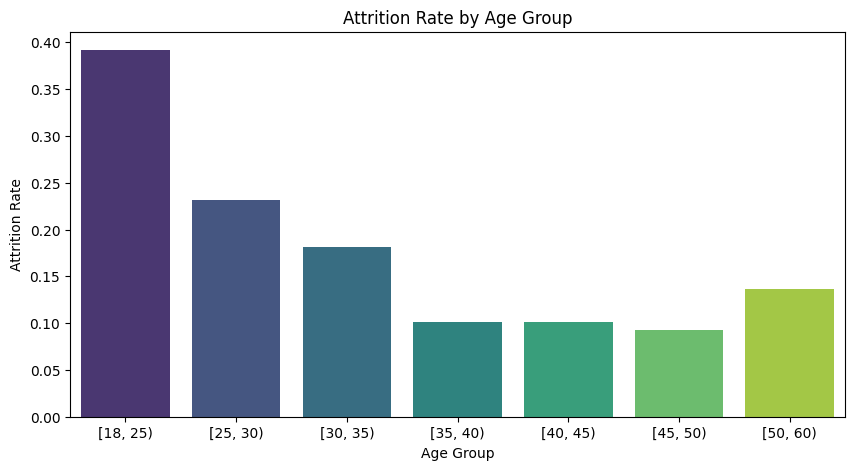

  Age_Group  Attrition
0  [18, 25)   0.391753
1  [25, 30)   0.231441
2  [30, 35)   0.181538
3  [35, 40)   0.101010
4  [40, 45)   0.100962
5  [45, 50)   0.092199
6  [50, 60)   0.136905


In [12]:
# 2) Average Attrition rate by Age group (binned)

df['Age_Group'] = pd.cut(df['Age'], bins=[18,25,30,35,40,45,50,60], right=False)

age_attrition = df.groupby('Age_Group')['Attrition'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=age_attrition, x='Age_Group', y='Attrition', palette='viridis')
plt.title("Attrition Rate by Age Group")
plt.ylabel("Attrition Rate")
plt.xlabel("Age Group")
plt.show()

print(age_attrition)

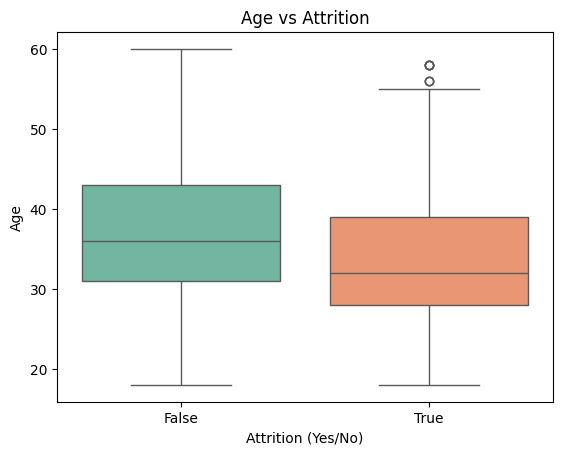

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
False,1233.0,37.561233,8.88836,18.0,31.0,36.0,43.0,60.0
True,237.0,33.607595,9.68935,18.0,28.0,32.0,39.0,58.0


In [15]:
# 3) Boxplot to compare distribution between attrition groups
# visually compare the distributions of MonthlyIncome for employees who left (Attrition = Yes) vs those who stayed (Attrition = No).
col = 'Age'

sns.boxplot(
    x='Attrition', 
    y=col, 
    hue='Attrition',          # <-- assign hue same as x
    data=df, 
    palette='Set2', 
    legend=False              # <-- suppress duplicate legend
)

plt.title(f'{col} vs Attrition')
plt.xlabel('Attrition (Yes/No)')
plt.ylabel(col)
plt.show()

df.groupby('Attrition')[col].describe()

### Salary vs JobSatisfaction → Does pay relate to satisfaction?

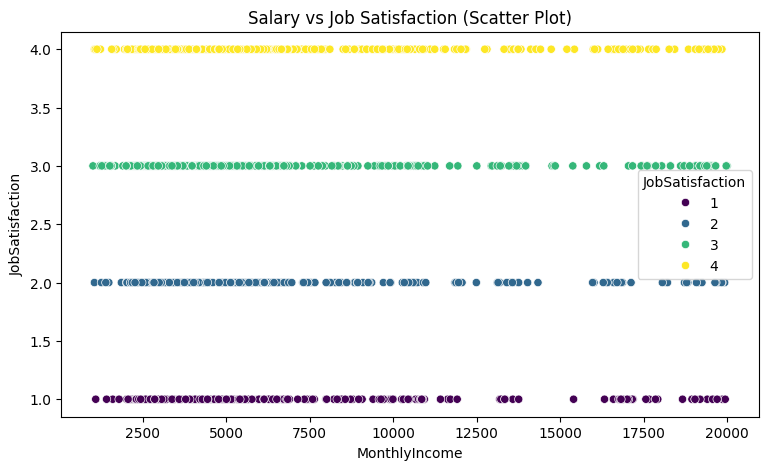

In [16]:
# 1) Scatterplot – direct relationship check
col = "MonthlyIncome"

plt.figure(figsize=(9,5))
sns.scatterplot(data=df, x=col, y='JobSatisfaction', hue='JobSatisfaction', palette='viridis')
plt.title("Salary vs Job Satisfaction (Scatter Plot)")
plt.show()

# Observation: I see no relation between Salary and Job Satisfaction

C:\Users\hi\AppData\Local\Temp\ipykernel_17440\2867761177.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='JobSatisfaction', y=col, palette='coolwarm')


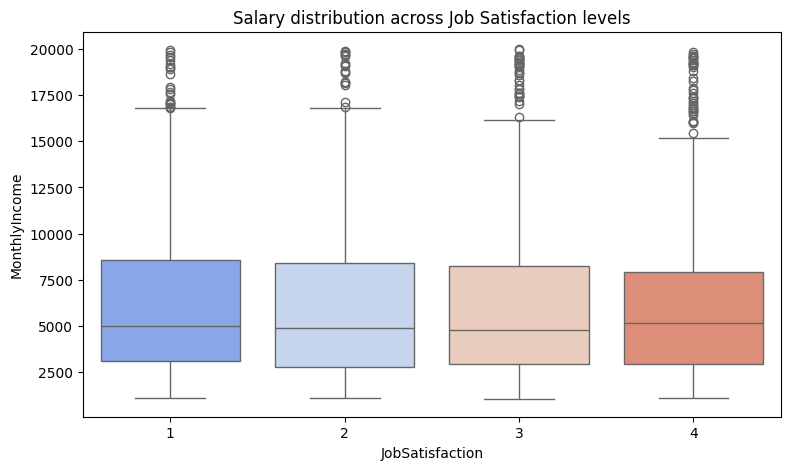

In [17]:
# 2) Boxplot – distribution of salary across satisfaction levels
col = "MonthlyIncome"

plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='JobSatisfaction', y=col, palette='coolwarm')
plt.title("Salary distribution across Job Satisfaction levels")
plt.show()

# Observation: I see no relation between Salary and Job Satisfaction

In [18]:
# 3) Correlation Value (Numerical Strength of relation)
col = "MonthlyIncome"

correlation = df[[col, 'JobSatisfaction']].corr().iloc[0,1]
print("Correlation between Salary and Job Satisfaction =", correlation)

# Observation: There seems to be 0 correlation between Salary and Job Satisfaction

Correlation between Salary and Job Satisfaction = -0.007156742355912745


C:\Users\hi\AppData\Local\Temp\ipykernel_17440\2717772103.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_avg, x='JobSatisfaction', y=col, palette='magma')


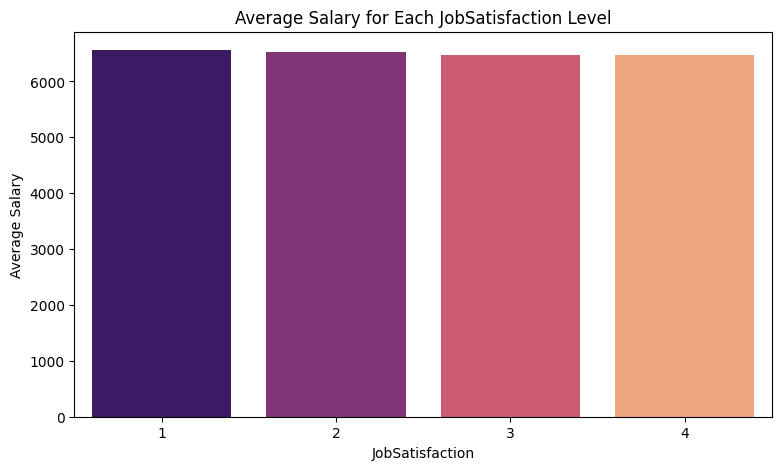

   JobSatisfaction  MonthlyIncome
0                1    6561.570934
1                2    6527.328571
2                3    6480.495475
3                4    6472.732026


In [20]:
# 4) Group level comparison
col = "MonthlyIncome"

group_avg = df.groupby('JobSatisfaction')[col].mean().reset_index()

plt.figure(figsize=(9,5))
sns.barplot(data=group_avg, x='JobSatisfaction', y=col, palette='magma')
plt.title("Average Salary for Each JobSatisfaction Level")
plt.ylabel("Average Salary")
plt.show()

print(group_avg)

# Observation: Avg. salary is same across each JobSatisfaction level.

## Education vs JobLevel → Is there a qualification gap?
check whether people with higher education tend to be in higher job levels — or if there is a mismatch (qualification gap).

In [26]:
print(df[["Education",]])    # "EducationField"
print("\nvalue_counts:\n", df[["Education",]].value_counts())

      Education
0             2
1             1
2             2
3             4
4             1
...         ...
1465          2
1466          1
1467          3
1468          3
1469          3

[1470 rows x 1 columns]

value_counts:
 Education
3            572
4            398
2            282
1            170
5             48
Name: count, dtype: int64


In [27]:
education_map = {
    1: "Below College",
    2: "College",
    3: "Bachelor",
    4: "Master",
    5: "Doctor"
}

df['Education_Label'] = df['Education'].map(education_map)

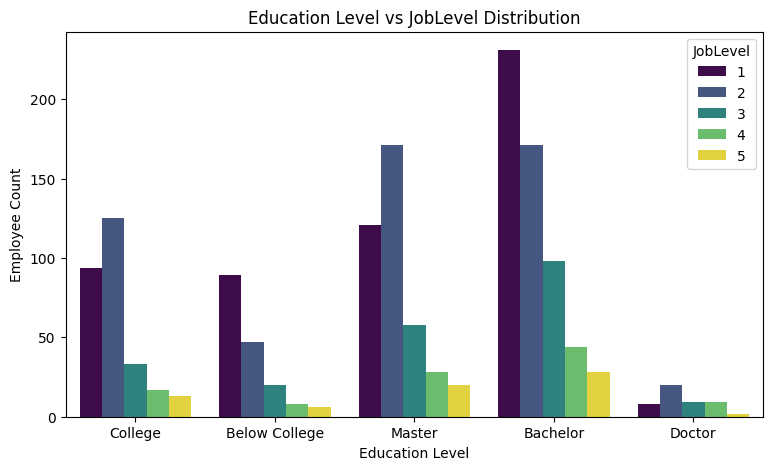

In [28]:
# 1) Countplot – number of employees per level

plt.figure(figsize=(9,5))
sns.countplot(data=df, x='Education_Label', hue='JobLevel', palette='viridis')
plt.title("Education Level vs JobLevel Distribution")
plt.xlabel("Education Level")
plt.ylabel("Employee Count")
plt.show()

C:\Users\hi\AppData\Local\Temp\ipykernel_17440\2285364483.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=edu_vs_job, x='Education_Label', y='JobLevel', palette='magma')


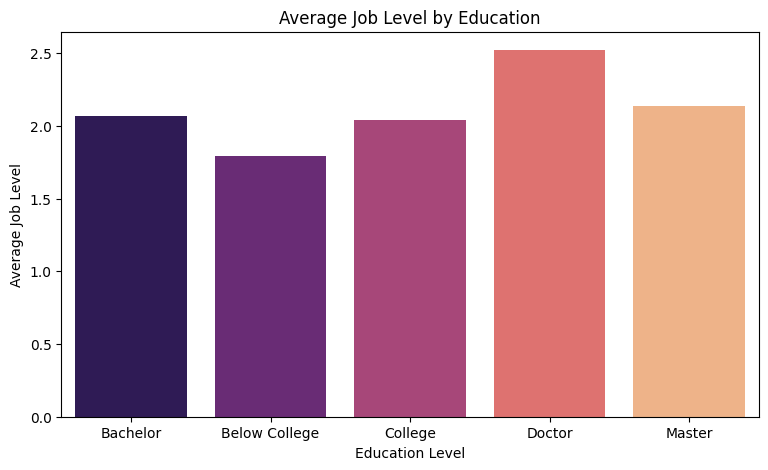

  Education_Label  JobLevel
0        Bachelor  2.068182
1   Below College  1.794118
2         College  2.042553
3          Doctor  2.520833
4          Master  2.133166


In [29]:
# 2) Average JobLevel for each Education Category
# ───────────────────────────────────────────────
edu_vs_job = df.groupby('Education_Label')['JobLevel'].mean().reset_index()

plt.figure(figsize=(9,5))
sns.barplot(data=edu_vs_job, x='Education_Label', y='JobLevel', palette='magma')
plt.title("Average Job Level by Education")
plt.ylabel("Average Job Level")
plt.xlabel("Education Level")
plt.show()

print(edu_vs_job)

C:\Users\hi\AppData\Local\Temp\ipykernel_17440\1637676180.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Education_Label', y='JobLevel', palette='coolwarm')


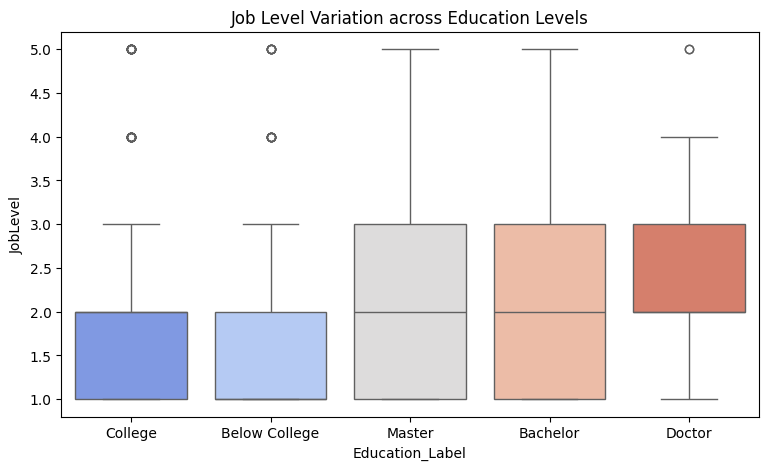

In [30]:
# 3) Boxplot – spread of job levels within each education group

plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Education_Label', y='JobLevel', palette='coolwarm')
plt.title("Job Level Variation across Education Levels")
plt.show()

## DistanceFromHome vs Attrition → Are long commuters leaving?

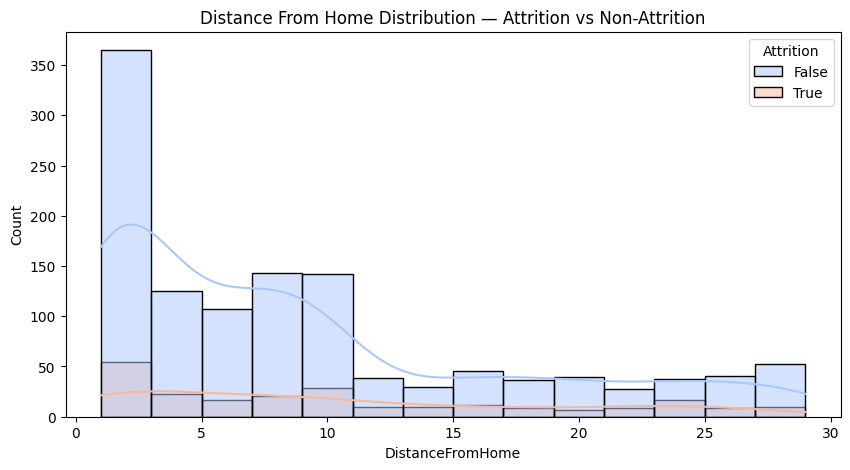

In [31]:
# 1) KDE/Histogram — Distribution comparison

plt.figure(figsize=(10,5))
sns.histplot(data=df, x='DistanceFromHome', hue='Attrition', kde=True, palette='coolwarm', multiple='layer')
plt.title("Distance From Home Distribution — Attrition vs Non-Attrition")
plt.show()

# It appears that attrition curve for True is flat

C:\Users\hi\AppData\Local\Temp\ipykernel_17440\2745129739.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='DistanceFromHome', palette='viridis')


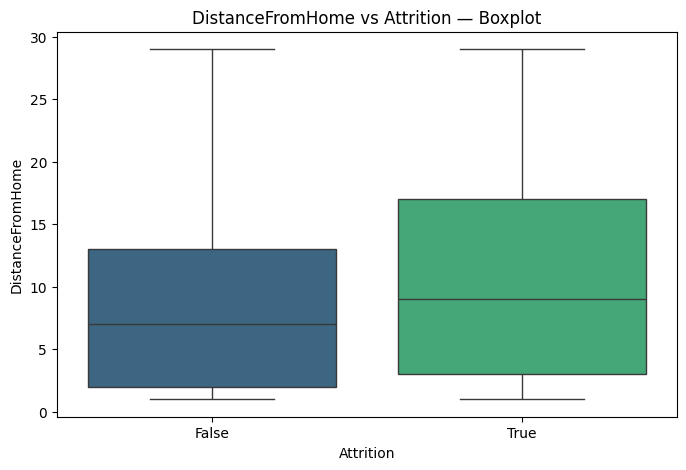

In [32]:
# 2) Boxplot — Difference in medians & spread

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome', palette='viridis')
plt.title("DistanceFromHome vs Attrition — Boxplot")
plt.show()

C:\Users\hi\AppData\Local\Temp\ipykernel_17440\1469938693.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_attrition = df.groupby('Distance_Group')['Attrition'].mean().reset_index()
C:\Users\hi\AppData\Local\Temp\ipykernel_17440\1469938693.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=distance_attrition, x='Distance_Group', y='Attrition', palette='magma')


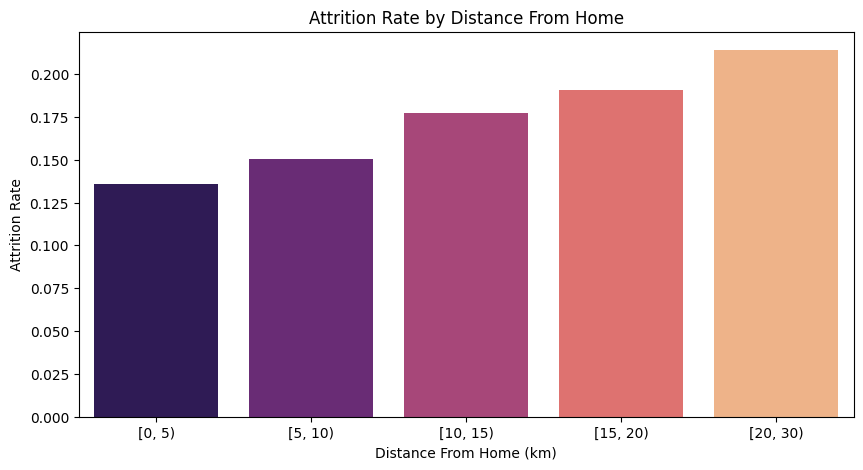

  Distance_Group  Attrition
0         [0, 5)   0.135802
1        [5, 10)   0.150134
2       [10, 15)   0.177143
3       [15, 20)   0.190476
4       [20, 30)   0.213974


In [34]:
# 3) Attrition rate based on distance buckets

df['Distance_Group'] = pd.cut(df['DistanceFromHome'], bins=[0,5,10,15,20,30], right=False)

distance_attrition = df.groupby('Distance_Group')['Attrition'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=distance_attrition, x='Distance_Group', y='Attrition', palette='magma')
plt.title("Attrition Rate by Distance From Home")
plt.xlabel("Distance From Home (km)")
plt.ylabel("Attrition Rate")
plt.show()

print(distance_attrition)

In [35]:
# 4) Correlation Strength

corr = df[['DistanceFromHome','Attrition']].corr().iloc[0,1]
print("Correlation between DistanceFromHome & Attrition =", corr)

Correlation between DistanceFromHome & Attrition = 0.07792358295570367
